# 01. Home Credit Default Risk - 탐색적 데이터 분석 (EDA)

**메인 테이블 `application_train.csv` 분석**

- **목표**: 신용 부도(`TARGET`) 예측을 위한 데이터 이해 - 무엇이 부도와 연관되는가?
- **규모**: 307,511명 × 122컬럼, 부도율 약 8%
- **분석 순서**: 구조 → TARGET 분포 → 결측 → 핵심변수(EXT_SOURCE) → 인구통계(나이·소득·직업) → 인사이트 정리

> 분석가 관점: 단순히 '돌려보기'가 아니라, 각 단계에서 **'그래서 부도와 무슨 상관?'** 을 계속 묻는다.

## 0. 환경 설정 & 라이브러리

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정 (한글 폰트 - Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)

print('준비 완료')

## 1. 데이터 로딩 & 기본 구조

가장 먼저 확인할 것: **행·열 수가 원본과 맞는지(307,511 × 122), 어떤 모습인지.**

In [2]:
df = pd.read_csv('../data/raw/application_train.csv')
print(f'shape: {df.shape}  (행 {df.shape[0]:,} / 열 {df.shape[1]})')
df.head()

shape: (307511, 122)  (행 307,511 / 열 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
# 컬럼 타입 분포 - 수치형 vs 범주형 비중 파악
print('타입별 컬럼 수:')
print(df.dtypes.value_counts())
print(f"\n수치형: {df.select_dtypes(include='number').shape[1]}개")
print(f"범주형(object): {df.select_dtypes(include='object').shape[1]}개")

## 2. TARGET 분포 - 불균형 확인

**왜 중요?** 부도율이 매우 낮으면(불균형), 정확도(accuracy)는 의미 없고 **AUC·AUPRC**로 평가해야 한다.\
→ 모델링 단계의 평가지표 선택을 좌우하는 출발점.

건수:
TARGET
0    282686
1     24825
Name: count, dtype: int64

부도율(TARGET=1): 8.07%   정상(TARGET=0): 91.93%
불균형 비율 약 1 : 11.4


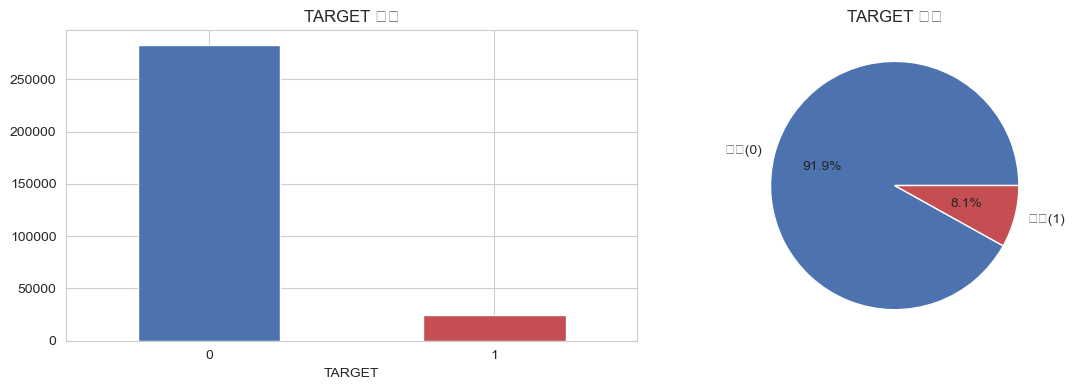

In [4]:
cnt = df['TARGET'].value_counts()
pct = df['TARGET'].value_counts(normalize=True) * 100
print('건수:'); print(cnt)
print(f'\n부도율(TARGET=1): {pct[1]:.2f}%   정상(TARGET=0): {pct[0]:.2f}%')
print(f'불균형 비율 약 1 : {cnt[0]/cnt[1]:.1f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cnt.plot.bar(ax=ax[0], title='TARGET 건수', rot=0, color=['#4C72B0', '#C44E52'])
pct.plot.pie(ax=ax[1], autopct='%.1f%%', labels=['정상(0)', '부도(1)'], colors=['#4C72B0', '#C44E52'], title='TARGET 비율')
ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

## 3. 결측치 분석

**왜 중요?** 122개 중 결측이 심한 컬럼(특히 주거건물 47개)을 어떻게 처리할지 결정해야 한다.\
→ '버릴 것 / 대치할 것 / 결측 자체가 신호인 것'을 구분.

In [5]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'결측수': miss, '결측률(%)': miss_pct})
miss_df = miss_df[miss_df['결측수'] > 0].sort_values('결측률(%)', ascending=False)
print(f'결측 있는 컬럼: {len(miss_df)}개 / 전체 {df.shape[1]}개')
print(f"결측률 50% 이상 컬럼: {(miss_df['결측률(%)'] >= 50).sum()}개")
miss_df.head(20)

결측 있는 컬럼: 67개 / 전체 122개
결측률 50% 이상 컬럼: 41개


,결측수,결측률(%)
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35


## 4. EXT_SOURCE - 핵심 예측 변수

`EXT_SOURCE_1/2/3` = **외부기관 신용 스코어**(정규화). 우리은행에서 다룬 기업 신용공여등급(BRR 등) 과 같은 '신용도를 등급·점수로 환산해 리스크 판단'하는 개념(대상이 기업→개인으로 다를 뿐).\
경험적으로 이 데이터에서 **부도 예측력 1위** 변수군. TARGET과의 상관·분포를 본다.

In [6]:
ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
print('기초통계:'); print(df[ext].describe().round(3))
print('\n결측률(%):'); print((df[ext].isnull().mean() * 100).round(2))
print('\nTARGET과 상관계수 (음수=점수 높을수록 안전):')
print(df[ext + ['TARGET']].corr()['TARGET'].drop('TARGET').round(4))

기초통계:
       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
count    134133.000    306851.000    246546.000
mean          0.502         0.514         0.511
std           0.211         0.191         0.195
min           0.015         0.000         0.001
25%           0.334         0.392         0.371
50%           0.506         0.566         0.535
75%           0.675         0.664         0.669
max           0.963         0.855         0.896

결측률(%):
EXT_SOURCE_1    56.38
EXT_SOURCE_2     0.21
EXT_SOURCE_3    19.83
dtype: float64

TARGET과 상관계수 (음수=점수 높을수록 안전):
EXT_SOURCE_1   -0.1553
EXT_SOURCE_2   -0.1605
EXT_SOURCE_3   -0.1789
Name: TARGET, dtype: float64


In [ ]:
# TARGET별 분포 - 부도(1)/정상(0) 그룹의 점수 분포가 갈리는지
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(ext):
    for t, c in [(0, '#4C72B0'), (1, '#C44E52')]:
        df.loc[df['TARGET'] == t, col].plot.kde(ax=axes[i], label=f'TARGET={t}', color=c)
    axes[i].set_title(col); axes[i].legend(); axes[i].set_xlim(0, 1)
plt.tight_layout(); plt.show()

## 5. DAYS_ 변수 변환 & 이상치 함정

`DAYS_BIRTH`, `DAYS_EMPLOYED`는 **신청일 기준 음수 일수**다. 사람이 읽을 수 있게 변환.\
특히 `DAYS_EMPLOYED`에 숨은 **`365243`(약 1000년) 이상치** = 무직자 placeholder. 이걸 잡아내는 게 실력.

In [9]:
# 나이 변환
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(1)
print('나이(AGE_YEARS) 통계:'); print(df['AGE_YEARS'].describe().round(1))

# DAYS_EMPLOYED 이상치 함정
print('\nDAYS_EMPLOYED 최댓값:', df['DAYS_EMPLOYED'].max(), '(=', round(df['DAYS_EMPLOYED'].max()/365), '년?!)')
anom = (df['DAYS_EMPLOYED'] == 365243)
print(f'365243 인 행: {anom.sum():,}개 ({anom.mean()*100:.1f}%)')
print('\n이 이상치 그룹 vs 정상 그룹의 부도율 비교:')
print(f"  이상치(무직 추정) 부도율: {df.loc[anom, 'TARGET'].mean()*100:.2f}%")
print(f"  정상 그룹 부도율:        {df.loc[~anom, 'TARGET'].mean()*100:.2f}%")
print(df.loc[anom, 'NAME_INCOME_TYPE'].value_counts())

나이(AGE_YEARS) 통계:
count    307511.0
mean         43.9
std          12.0
min          20.5
25%          34.0
50%          43.2
75%          53.9
max          69.1
Name: AGE_YEARS, dtype: float64

DAYS_EMPLOYED 최댓값: 365243 (= 1001 년?!)
365243 인 행: 55,374개 (18.0%)

이 이상치 그룹 vs 정상 그룹의 부도율 비교:
  이상치(무직 추정) 부도율: 5.40%
  정상 그룹 부도율:        8.66%
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


## 6. 인구통계 · 소득 · 대출 vs 부도율

나이대·소득·대출액이 부도와 어떤 관계인지. **'젊을수록/대출액 클수록 위험한가?'** 같은 가설을 눈으로 확인.

나이대별 부도율(%):
AGE_BIN
(20, 30]    11.43
(30, 40]     9.59
(40, 50]     7.63
(50, 60]     6.12
(60, 70]     4.93
Name: TARGET, dtype: float64


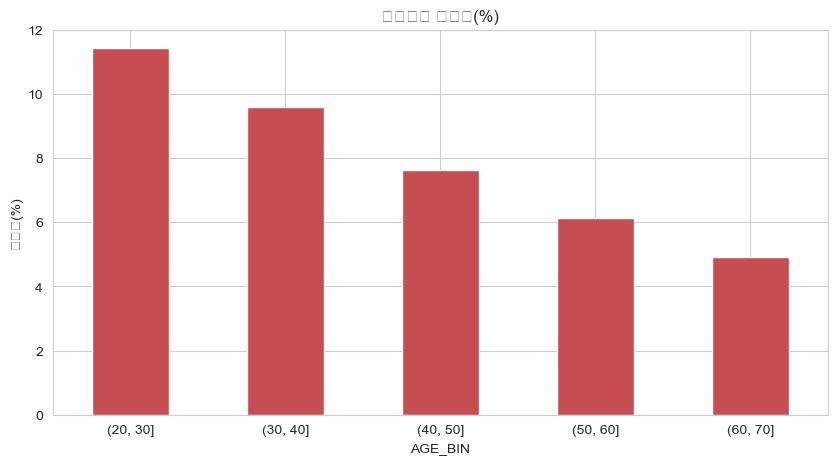

In [10]:
# 나이대별 부도율
df['AGE_BIN'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70])
age_def = (df.groupby('AGE_BIN')['TARGET'].mean() * 100).round(2)
print('나이대별 부도율(%):'); print(age_def)
age_def.plot.bar(title='나이대별 부도율(%)', rot=0, color='#C44E52'); plt.ylabel('부도율(%)'); plt.show()

In [ ]:
# 대출액·소득 - 부도/정상 그룹 비교
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
    g = df.groupby('TARGET')[col].median()
    print(f'{col:20s} | 정상 중앙값 {g[0]:>12,.0f} | 부도 중앙값 {g[1]:>12,.0f}')

# 파생: 소득 대비 대출 비율(DTI 유사), 소득 대비 상환부담
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
print('\n소득대비 대출비율(CREDIT_INCOME_RATIO) TARGET별 중앙값:')
print(df.groupby('TARGET')['CREDIT_INCOME_RATIO'].median().round(2))
print(df.groupby('TARGET')['ANNUITY_INCOME_RATIO'].median().round(4))

## 7. 범주형 변수 vs 부도율

교육수준·소득유형·가족상태 등 **범주별 부도율 격차**를 본다. 격차가 큰 변수가 좋은 예측변수.

In [14]:
for col in ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE']:
    print(f'\n=== {col} 별 부도율(%) ===')
    rate = (df.groupby(col)['TARGET'].mean() * 100).round(2).sort_values(ascending=False)
    print(rate)

df.groupby('NAME_INCOME_TYPE').agg(부도율=('TARGET','mean'), 표본수=('TARGET','size')).sort_values('표본수',ascending=False)


=== NAME_EDUCATION_TYPE 별 부도율(%) ===
NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64

=== NAME_INCOME_TYPE 별 부도율(%) ===
NAME_INCOME_TYPE
Maternity leave         40.00
Unemployed              36.36
Working                  9.59
Commercial associate     7.48
State servant            5.75
Pensioner                5.39
Businessman              0.00
Student                  0.00
Name: TARGET, dtype: float64

=== NAME_FAMILY_STATUS 별 부도율(%) ===
NAME_FAMILY_STATUS
Civil marriage          9.94
Single / not married    9.81
Separated               8.19
Married                 7.56
Widow                   5.82
Unknown                 0.00
Name: TARGET, dtype: float64

=== OCCUPATION_TYPE 별 부도율(%) ===
OCCUPATION_TYPE
Low-skill Laborers       17.15
Drivers                  11.33
Waiters/barmen staff     1

,부도율,표본수
NAME_INCOME_TYPE,,
Working,0.095885,158774
Commercial associate,0.074843,71617
Pensioner,0.053864,55362
State servant,0.057550,21703
Unemployed,0.363636,22
Student,0.000000,18
Businessman,0.000000,10
Maternity leave,0.400000,5


## 8. EDA 핵심 인사이트 (10개)

  ### TARGET & 데이터 구조
  1. **불균형**: 부도율 8.07%(정상 91.9%). 정확도는 무의미 → 평가지표 **AUC·AUPRC**, 불균형 처리(class_weight 등) 필요.
  2. **결측 구조**: 67개 컬럼 결측, 50%+ 41개(대부분 주거건물 47개). 제거 또는 결측플래그. `OWN_CAR_AGE`는 구조적
  결측(차 없음)이라 별도 처리.

  ### 핵심 예측 변수
  3. **EXT_SOURCE(최강)**: 3개 모두 TARGET과 음의 상관(-0.15~-0.18), 122변수 중 1~3위. KDE 분포가 부도/정상 명확히 분리.
  `EXT_SOURCE_2`(결측0.2%)는 완전+강력해 핵심, 1·3은 결측 처리 후 활용(평균 파생 고려).
  4. **DAYS_EMPLOYED 이상치**: 365243(18%) = 연금수급자 99.96%로 규명(무직 아님). 부도율 5.4% < 정상 8.66%로 오히려 안전
  → NaN + 고용정보이상 플래그(안전 신호)로 처리.
  5. **나이**: 단조 감소(20대 11.4% → 60대 4.9%, 2.3배). 고령 연금수급자와 연결. 선형상관은 약하나 구간화하면 명확 →
  트리모델에 유효.

  ### 약한 변수 & 함정
  6. **금액 변수는 약함**: 소득·대출·소득대비대출비율 부도 구분력 약함(3.27 vs 3.25). 대출심사 통제(selection bias)
  추정. `ANNUITY_INCOME_RATIO`만 방향 있음(16.9% vs 16.2%)이나 효과크기 작음. ※30만 표본이라 통계적 유의 ≠ 예측력.
  7. **범주형**: 교육수준 강력(중졸 10.93% → 석박사 1.83%, 6배, 단조). 소득유형은 표본수 함정(육아휴직40%·사업가0%는
  표본 5~22개라 무의미) → 신뢰범주: 직장인 9.6%(위험) > 공무원·연금 5%대(안전). 직업도 Low-skill Laborers 17.2% vs
  Accountants 4.8%로 격차 큼.

  ### 종합 & 다음
  8. **일관된 스토리**: '연금수급자=안전'이 이상치(5.4%) → 나이(60대 4.9%) → 소득유형(5.39%) 세 경로에서 일치.
  9. **변수 우선순위**: EXT_SOURCE > 교육·나이(구간) > 금액변수(약함). 모델링 시 EXT_SOURCE 결측 처리가 성능 좌우.
  10. **다음**: `02_hypothesis_testing` - t-test·chi-square로 검증(effect size 동반) → 이후 `bureau` 조인(Phase 2).